<a href="https://colab.research.google.com/github/rutijanasandra-svg/ores5160-2025/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CSV

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Provisional_COVID-19_Deaths_by_Sex_and_Age_20260429.csv to Provisional_COVID-19_Deaths_by_Sex_and_Age_20260429.csv


In [ ]:
df = pd.read_csv("Provisional_COVID-19_Deaths_by_Sex_and_Age_20260429.csv")

/tmp/ipykernel_54236/355242695.py:1: DtypeWarning: Columns (11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Provisional_COVID-19_Deaths_by_Sex_and_Age_20260429.csv")


In [ ]:
df.head()

,Data As Of,Start Date,End Date,Group,Year,Month,State,Sex,Age Group,COVID-19 Deaths,Total Deaths,Pneumonia Deaths,Pneumonia and COVID-19 Deaths,Influenza Deaths,"Pneumonia, Influenza, or COVID-19 Deaths",Footnote
0,09/27/2023,01/01/2020,09/23/2023,By Total,NaN,NaN,United States,All Sexes,All Ages,"1,146,774","12,303,399","1,162,844","569,264","22,229","1,760,095",NaN
1,09/27/2023,01/01/2020,09/23/2023,By Total,NaN,NaN,United States,All Sexes,Under 1 year,519,"73,213","1,056",95,64,"1,541",NaN
2,09/27/2023,01/01/2020,09/23/2023,By Total,NaN,NaN,United States,All Sexes,0-17 years,"1,696","130,970","2,961",424,509,"4,716",NaN
3,09/27/2023,01/01/2020,09/23/2023,By Total,NaN,NaN,United States,All Sexes,1-4 years,285,"14,299",692,66,177,"1,079",NaN
4,09/27/2023,01/01/2020,09/23/2023,By Total,NaN,NaN,United States,All Sexes,5-14 years,509,"22,008",818,143,219,"1,390",NaN


In [ ]:
df.shape

(137700, 16)

In [ ]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

In [ ]:
df.isnull().sum()

,0
Data As Of,0
Start Date,0
End Date,0
Group,0
Year,2754
Month,13770
State,0
Sex,0
Age Group,0
COVID-19 Deaths,39430


In [ ]:
df = df.fillna("Unknown")

In [ ]:
df['COVID-19 Deaths'] = (
    df['COVID-19 Deaths']
    .astype(str)
    .str.replace(',', '')
)

df['COVID-19 Deaths'] = pd.to_numeric(
    df['COVID-19 Deaths'],
    errors='coerce'
)

In [ ]:
def validate_deaths(x):
    if x < 0:
        raise ValueError("Deaths cannot be negative")

In [ ]:
for value in df['COVID-19 Deaths'].dropna():
    try:
        validate_deaths(value)
    except ValueError as e:
        print(e)

In [ ]:
sex_summary = df.groupby('Sex')['COVID-19 Deaths'].sum()
print(sex_summary)

Sex
All Sexes    15429720.0
Female        6816885.0
Male          8569545.0
Name: COVID-19 Deaths, dtype: float64


In [ ]:
pivot = df.pivot_table(
    values='COVID-19 Deaths',
    index='Age Group',
    columns='Sex',
    aggfunc='sum'
)

pivot.head()

Sex,All Sexes,Female,Male
Age Group,,,
0-17 years,8160.0,3402.0,4046.0
1-4 years,1036.0,444.0,498.0
15-24 years,15806.0,5860.0,8869.0
18-29 years,39032.0,14231.0,23091.0
25-34 years,70764.0,26004.0,42534.0


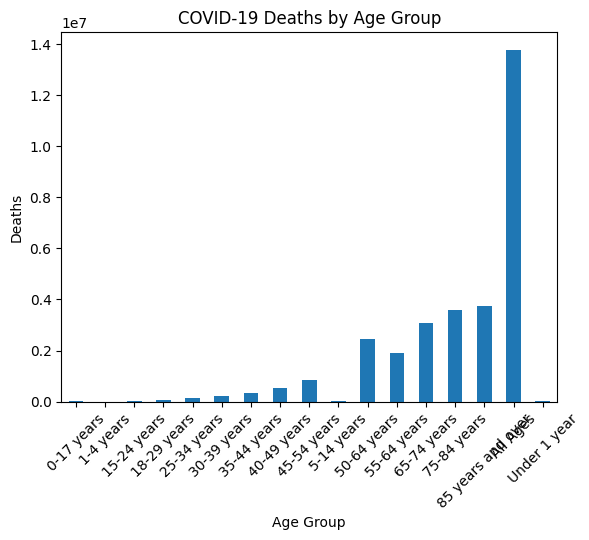

In [ ]:
import matplotlib.pyplot as plt

age_deaths = df.groupby('Age Group')['COVID-19 Deaths'].sum()

age_deaths.plot(kind='bar')

plt.title('COVID-19 Deaths by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Deaths')

plt.xticks(rotation=45)

plt.show()

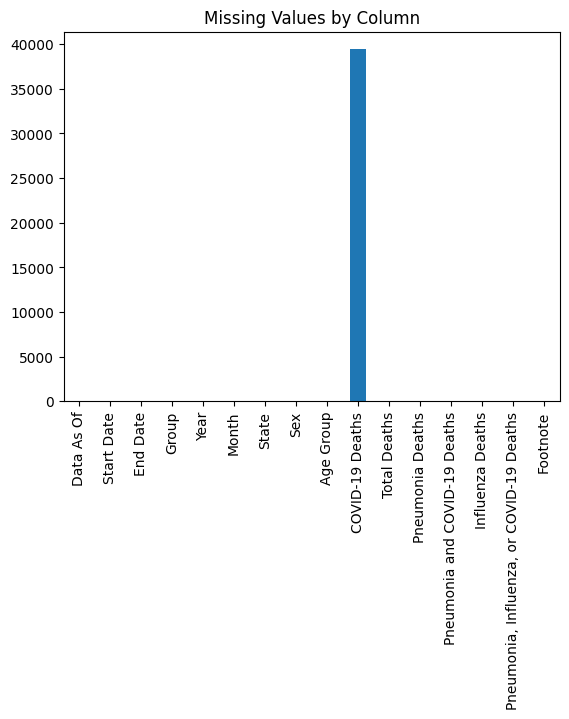

In [ ]:
df.isnull().sum().plot(kind='bar')

plt.title('Missing Values by Column')

plt.show()

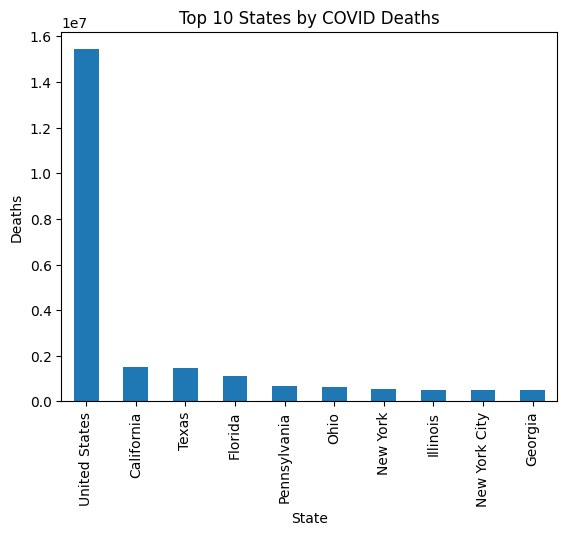

In [ ]:
top_states = (
    df.groupby('State')['COVID-19 Deaths']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states.plot(kind='bar')

plt.title('Top 10 States by COVID Deaths')

plt.ylabel('Deaths')

plt.show()

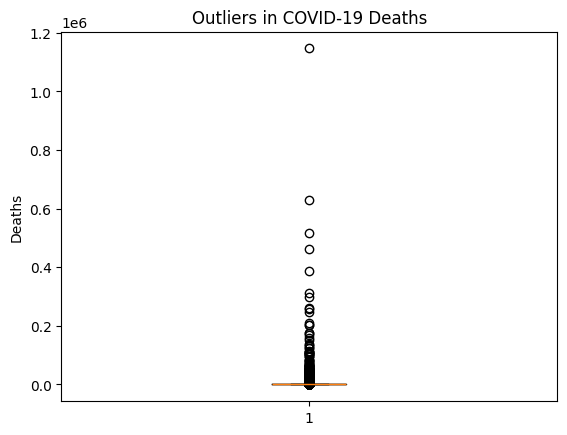

In [ ]:
plt.boxplot(df["COVID-19 Deaths"].dropna())
plt.title("Outliers in COVID-19 Deaths")
plt.ylabel("Deaths")
plt.show()

SQL

In [ ]:
import sqlite3

conn = sqlite3.connect("health.db")
df.to_sql("covid_data", conn, if_exists="replace", index=False)

137700

In [ ]:
pd.read_sql("SELECT COUNT(*) FROM covid_data", conn)

,COUNT(*)
0,137700


JSON/API Ingestion

In [ ]:
url = "https://disease.sh/v3/covid-19/all"

response = requests.get(url)

covid_data = response.json()

print(covid_data)

{'updated': 1778616445219, 'cases': 704753890, 'todayCases': 0, 'deaths': 7010681, 'todayDeaths': 0, 'recovered': 675619811, 'todayRecovered': 790, 'active': 22123398, 'critical': 34794, 'casesPerOneMillion': 90413, 'deathsPerOneMillion': 899.4, 'tests': 7026505313, 'testsPerOneMillion': 884400.59, 'population': 7944935131, 'oneCasePerPeople': 0, 'oneDeathPerPeople': 0, 'oneTestPerPeople': 0, 'activePerOneMillion': 2784.59, 'recoveredPerOneMillion': 85037.8, 'criticalPerOneMillion': 4.38, 'affectedCountries': 231}


In [ ]:
api_df = pd.DataFrame([{
    "Cases": covid_data["cases"],
    "Deaths": covid_data["deaths"],
    "Recovered": covid_data["recovered"],
    "Active": covid_data["active"],
    "Critical": covid_data["critical"]
}])

api_df

,Cases,Deaths,Recovered,Active,Critical
0,704753890,7010681,675619811,22123398,34794


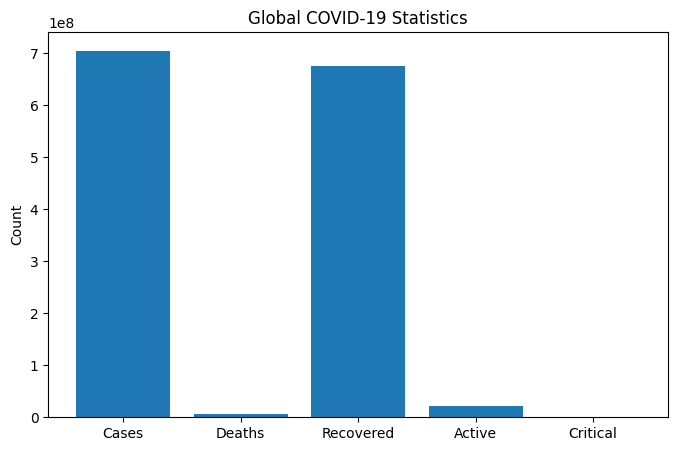

In [ ]:
categories = ["Cases", "Deaths", "Recovered", "Active", "Critical"]

values = [
    covid_data["cases"],
    covid_data["deaths"],
    covid_data["recovered"],
    covid_data["active"],
    covid_data["critical"]
]

plt.figure(figsize=(8,5))
plt.bar(categories, values)

plt.title("Global COVID-19 Statistics")
plt.ylabel("Count")

plt.show()

HTML Scraping

In [ ]:
import pandas as pd
import requests

wiki_url = "https://en.wikipedia.org/wiki/COVID-19_pandemic_by_country_and_territory"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(wiki_url, headers=headers)

tables = pd.read_html(response.text)

print(len(tables))

/tmp/ipykernel_1275/1266530572.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


67


In [ ]:
from bs4 import BeautifulSoup
import requests
import pandas as pd

In [ ]:
wiki_url = "https://en.wikipedia.org/wiki/COVID-19_pandemic_by_country_and_territory"

headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(wiki_url, headers=headers)

In [ ]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)

COVID-19 pandemic by country and territory - Wikipedia


In [ ]:
covid_scrape_df = tables[0]

covid_scrape_df.head()

,COVID-19 pandemic,COVID-19 pandemic.1
0,"Confirmed deaths per 100,000 population,[1][no...","Confirmed deaths per 100,000 population,[1][no..."
1,Disease,COVID-19
2,Virus strain,SARS-CoV-2
3,Source,"Probably bats, possibly via pangolins[2][3][4]"
4,Location,Worldwide


In [ ]:
covid_scrape_df.columns = covid_scrape_df.columns.get_level_values(0)

covid_scrape_df.head()

,COVID-19 pandemic,COVID-19 pandemic.1
0,"Confirmed deaths per 100,000 population,[1][no...","Confirmed deaths per 100,000 population,[1][no..."
1,Disease,COVID-19
2,Virus strain,SARS-CoV-2
3,Source,"Probably bats, possibly via pangolins[2][3][4]"
4,Location,Worldwide


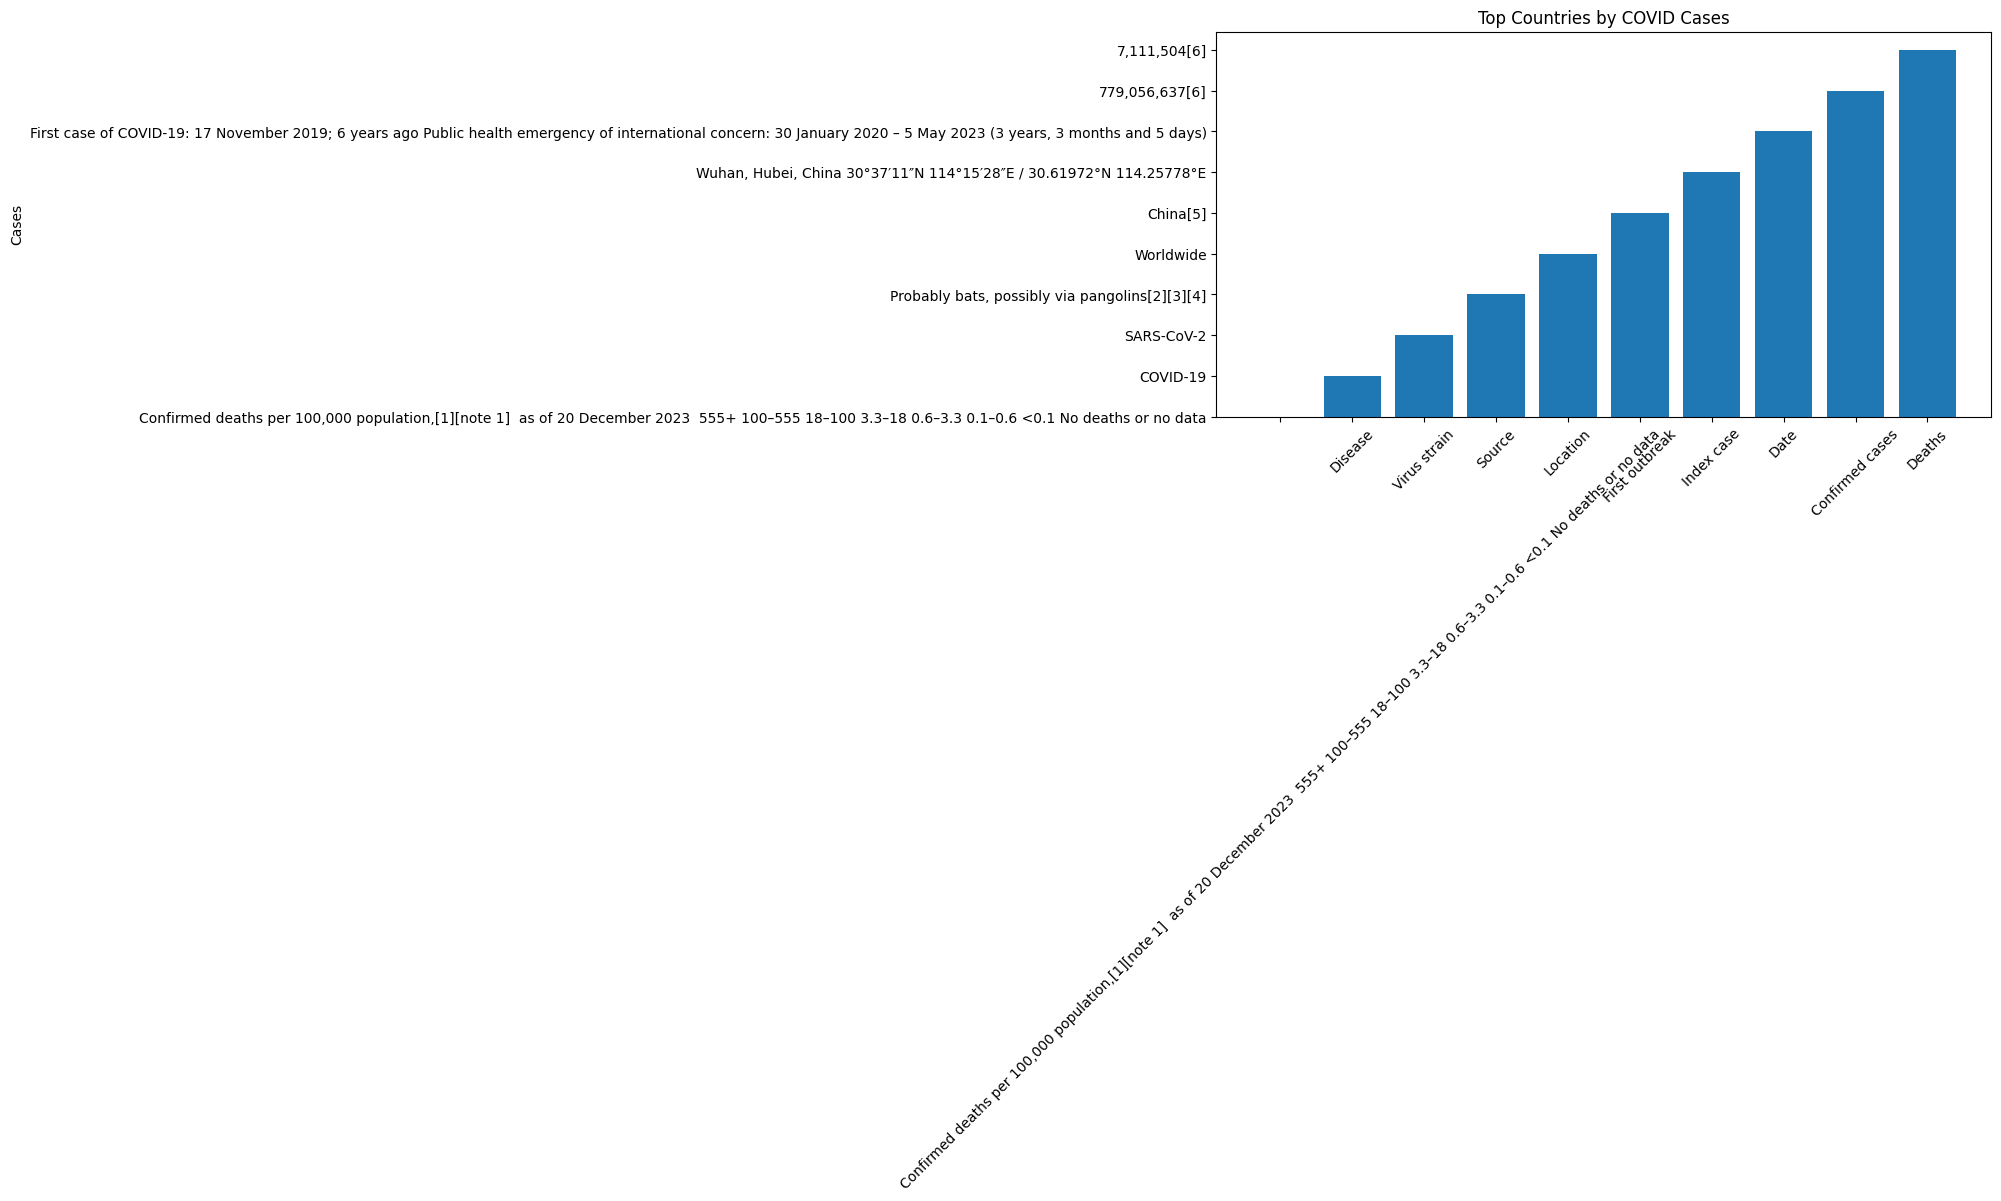

In [ ]:
import matplotlib.pyplot as plt

top10 = covid_scrape_df.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10.iloc[:,0], top10.iloc[:,1])

plt.xticks(rotation=45)
plt.title("Top Countries by COVID Cases")
plt.ylabel("Cases")

plt.show()